# Homework 03: Learning Curves and Training Workflow

**Points:** 85

In this assignment, you will learn how to design, train, and evaluate neural networks by systematically exploring key design choices. Your focus will be on developing an effective **training workflow** — using learning curves and validation metrics to guide your decisions.

We'll use the **Forest Cover Type (Covertype) dataset,** which has ~581k tabular records with 54 cartographic/topographic features (elevation, aspect, slope, soil and wilderness indicators) used to predict one of seven tree cover types in Colorado’s Roosevelt National Forest. It’s a large, mildly imbalanced multi-class benchmark commonly used to compare classical ML and deep learning on tabular data.

We will start with a **baseline model** (two hidden layers of sizes 64 and 32), and gradually introduce and tune different hyperparameters. Each of the first five problems considers  different hyperparameter choices, and the last problem is your chance to use what you have learned to design your best model:

1. **Activation function** – Compare ReLU, sigmoid, and tanh to see which provides the best accuracy.
2. **Learning rate** – Explore a range of learning rates and identify which balances convergence speed and stability.
3. **Dropout** – Investigate how different dropout rates reduce overfitting and where they are most effective.
4. **L2 regularization** – Experiment with weight penalties to encourage simpler models and avoid memorization.
5. **Dropout + L2** – Combine both regularization techniques and study their interaction.
6. **Best model design** – Use all your insights to build and train your strongest model, with the option to try **learning rate scheduling** for further improvement.

In this homework, you will use **early stopping** to select the "best" model at the epoch of **minimum validation loss**, and you will report the **validation accuracy** of that selected model as the primary measure of performance. Test accuracy is reported for reference but is not used for model selection.

> **Note:** Throughout this homework, best always refers to the model selected by early stopping at the epoch of minimum validation loss. Do not report metrics from the final training epoch unless explicitly instructed.

By the end of this homework, you will not only understand how different hyperparameters affect training and generalization, but also gain hands-on practice in building a disciplined workflow for model development.

There are 10 graded problems, worth 8 points each, with 5 points for free if you complete the homework. 

In [ ]:
# Cell 0: Ensure required libraries are installed in this notebook environment

# %pip install numpy pandas matplotlib seaborn scikit-learn tensorflow -q

# Optional: upgrade pip quietly (only if needed)
# %pip install --upgrade pip -q

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
# Useful imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import time
import os

from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.utils import class_weight

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input,Dropout
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers.schedules import ExponentialDecay


from tensorflow.keras.datasets import fashion_mnist

# utility code

random_seed = 42

def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Suppresses INFO and WARNING messages


2026-02-14 02:29:14.988994: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-14 02:29:15.075516: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-14 02:29:17.640709: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
# Utility function to plot learning curves and keep track of all results

# Call `print_results()` to see listing of all results logged so far


def plot_learning_curves(hist, title, verbose=True):
    
    val_losses = hist.history['val_loss']
    min_val_loss = min(val_losses)
    min_val_epoch = val_losses.index(min_val_loss)
    val_acc_at_min_loss = hist.history['val_accuracy'][min_val_epoch]

    epochs = range(1, len(val_losses) + 1)  # epoch numbers starting at 1

    fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

    # --- Loss Plot ---
    axs[0].plot(epochs, hist.history['loss'], label='train loss')
    axs[0].plot(epochs, hist.history['val_loss'], label='val loss')
    axs[0].scatter(min_val_epoch + 1, min_val_loss, color='red', marker='x', s=50, label='min val loss')
    axs[0].set_title(f'{title} - Categorical Cross-Entropy Loss')
    axs[0].set_ylabel('Loss')
    axs[0].legend()
    axs[0].grid(True)

    # --- Accuracy Plot ---
    axs[1].plot(epochs, hist.history['accuracy'], label='train acc')
    axs[1].plot(epochs, hist.history['val_accuracy'], label='val acc')
    axs[1].scatter(min_val_epoch + 1, val_acc_at_min_loss, color='red', marker='x', s=50, label='acc @ min val loss')
    axs[1].set_title(f'{title} - Accuracy')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('Accuracy')
    axs[1].legend()
    axs[1].grid(True)
    axs[1].set_ylim(0, 1.05)

    plt.tight_layout()
    plt.show()

    if verbose:
        print(f"Final Training Loss:            {hist.history['loss'][-1]:.4f}")
        print(f"Final Training Accuracy:        {hist.history['accuracy'][-1]:.4f}")
        print(f"Final Validation Loss:          {hist.history['val_loss'][-1]:.4f}")
        print(f"Final Validation Accuracy:      {hist.history['val_accuracy'][-1]:.4f}")
        print(f"Minimum Validation Loss:        {min_val_loss:.4f} (Epoch {min_val_epoch + 1})")
        print(f"Validation Accuracy @ Min Loss: {val_acc_at_min_loss:.4f}")

    results[title] = (val_acc_at_min_loss,min_val_epoch + 1)

results = {}

**The plotting function will record the validation accuracy for each experiment, using the plot title as key. The next function will print these out (see the last cell in the notebook).**


In order to see all results, you must give a different plot title to each experiment.

In [3]:
def print_results():
    for title, (acc, ep) in sorted(results.items(), 
                                   key=lambda kv: kv[1][0],   # kv[1] is (acc, epoch); [0] is acc
                                   reverse=True
                                  ):
        print(f"{title:<40}\t{acc:.4f}")

### Wrapper to train, display results, and run test set

We assume multi-class classification, and allow setting various parameters for training. 

In [4]:
# Uses globals X_train,y_train,X_val,y_val

def train_and_test(model, 
                   epochs        = 500,                   # Just needs to be bigger than early stop point
                   lr_schedule   = 0.001,                 # Adam default / 10 seems to work well for this dataset
                   optimizer     = "Adam",
                   title         = "Learning Curves",
                   batch_size    = 64,                     # experiments confirmed this was optimal with other parameters at default
                   use_early_stopping = True,
                   patience      = 10,                                       
                   min_delta     = 0.0001,                 
                   callbacks     = [],                     # for extra callbacks other than early stopping
                   verbose       = 0,
                   return_history = False
                  ):

    print(f"\n{title}\n")


    if optimizer == "Adam":
        opt = Adam(learning_rate=lr_schedule) 
    else:
        opt = optimizer
    
    #Compiling the model
    model.compile(optimizer=opt, 
                  loss="sparse_categorical_crossentropy", 
                  metrics=["accuracy"]
                 )

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=patience,
        min_delta=min_delta,
        restore_best_weights=True,               # this will mean that the model which produced the smallest validation loss will be returned
        verbose=verbose
    )
    

    if use_early_stopping:
        cbs=[early_stop] + callbacks
    else:
        cbs=callbacks

    # start timer
    start = time.time()
    
    # Fit the model with early stopping
    history = model.fit(X_train, y_train,
                        epochs=epochs,
                        batch_size=batch_size,
                        validation_data=(X_val, y_val),       # must use stratified validation set
                        callbacks=cbs,
                        verbose=verbose
                       )

    if use_early_stopping:
        best_epoch = early_stop.best_epoch
        best_acc   = history.history['val_accuracy'][best_epoch]
    else:
        best_epoch = np.argmax(history.history['val_accuracy'])
        best_acc   = history.history['val_accuracy'][best_epoch]
    
    # Plot training history
    plot_learning_curves(history, title=title)

    # Evaluate on test data
    test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
    
    print(f"\nTest Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")

    print(f"\nValidation-Test Gap (accuracy): {abs(best_acc - test_accuracy):.6f}")
    
    # Record end time and print execution time
    end = time.time()
    print(f"\nExecution Time: " + format_hms(end-start))

    if return_history:
        return history

### Load the dataset and extract a stratified subset

This data set is rather large (581,012 samples) and unbalanced, but for the purposes of this homework, we use a much smaller set, and select samples so that it is balanced. 

In [5]:
# complete cell: load, balance, split into X_train/y_train/x_val/y_val/X_test/y_test, and standardize
from collections import Counter
from sklearn.datasets import fetch_covtype
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# 1) load
x, y = fetch_covtype(return_X_y=True)  # y in {1..7}
print("full dataset shape:", x.shape)

# 2) build a perfectly balanced subset across 7 classes (no replacement)
classes, counts = np.unique(y, return_counts=True)
# min_count = counts.min()  # size of rarest class                         # You can modify this parameter to increase the size of the dataset, but above
min_count = 1000                                                           # counts.min() you'll produce an unbalanced set. 


rng = np.random.default_rng(42)

idx_list = []
for c in classes:
    c_idx = np.where(y == c)[0]
    chosen = rng.choice(c_idx, size=min_count, replace=False)
    idx_list.append(chosen)

idx_bal = np.concatenate(idx_list)
rng.shuffle(idx_bal)

X_sub = x[idx_bal]
y_sub = y[idx_bal] - 1  # relabel to {0..6} for keras
print("balanced subset shape:", X_sub.shape, "class counts:", dict(Counter(y_sub)))

# 3) stratified 60/20/20 split (train/val/test)
test_size = 0.20
val_size = 0.20  # of the whole dataset

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_sub, y_sub, test_size=test_size, random_state=random_seed, stratify=y_sub
)
val_size_rel = val_size / (1.0 - test_size)  # e.g., 0.20 / 0.80 = 0.25

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=val_size_rel, random_state=random_seed, stratify=y_trainval
)

# 4) standardize using train-only stats (float32 for tensorflow friendliness)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_val   = scaler.transform(X_val).astype(np.float32)
X_test  = scaler.transform(X_test).astype(np.float32)

# 5) quick sanity checks
def show_counts(name, y_arr):
    c = Counter(y_arr)
    total = sum(c.values())
    print(f"{name}: total={total}, per-class={dict(c)}")

print("shapes:", "X_train", X_train.shape, "X_val", X_val.shape, "X_test", X_test.shape)
show_counts("train", y_train)
show_counts("val  ", y_val)
show_counts("test ", y_test)

# you now have: X_train, y_train, X_val, y_val, X_test, y_test

# Looks like integer encoded multi-class, let's check and define the global n_classes

labels = np.unique(y_train)

n_classes = len(labels)

print("class labels:",labels)


full dataset shape: (581012, 54)
balanced subset shape: (7000, 54) class counts: {np.int32(2): 1000, np.int32(0): 1000, np.int32(4): 1000, np.int32(5): 1000, np.int32(1): 1000, np.int32(3): 1000, np.int32(6): 1000}
shapes: X_train (4200, 54) X_val (1400, 54) X_test (1400, 54)
train: total=4200, per-class={np.int32(2): 600, np.int32(1): 600, np.int32(0): 600, np.int32(3): 600, np.int32(5): 600, np.int32(4): 600, np.int32(6): 600}
val  : total=1400, per-class={np.int32(1): 200, np.int32(6): 200, np.int32(5): 200, np.int32(4): 200, np.int32(3): 200, np.int32(2): 200, np.int32(0): 200}
test : total=1400, per-class={np.int32(0): 200, np.int32(6): 200, np.int32(2): 200, np.int32(3): 200, np.int32(4): 200, np.int32(5): 200, np.int32(1): 200}
class labels: [0 1 2 3 4 5 6]


## Prelude: Defining a model builder

In order to facilitate our experimentation, we'll write a function which builds models according to specifications:

- How many layers
- How wide each layer is
- How much dropout in each layer
- How much L2 Regularization in each layer

This is a fairly standard practice in ML, since the structure of simple models is fairly predictable and can be specified by a few hyperparameters. 

In [6]:
# This function will build a multi-class classifier with dropout and L2 regularization.
# You must specify the number of input features, the number of classes, and a list of layer hyperparameters
# in the form  [ ...., (width, activation function, L2 lambda, dropout rate), .... ]

# Note that when adding dropout, this appears as a separate layer, but it has no parameters to be trained. 

def build_model(n_inputs,layer_list,n_classes):
    layers = [ Input(shape=(n_inputs,)) ]
    for (width,act,l2_lambda,dropout_rate) in layer_list:
        layers.append( Dense(width, activation=act, kernel_regularizer=regularizers.l2(l2_lambda)) )
        if dropout_rate > 0:
            layers.append( Dropout(dropout_rate) )
    layers.append( Dense(n_classes, activation='softmax') )
    return models.Sequential( layers )


**Example: To build the following model:**

In [7]:
model = models.Sequential(
   [
    Input(shape=(X_train.shape[1],)),                              
    Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.0)),              # 0.0 means no regularization applied; no dropout, so no Dropout layer necessary
    Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.3),
    Dense(n_classes, activation='softmax')
   ]
)

model.summary()

2026-02-14 02:30:16.731872: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         3,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,831 (22.78 KB)

 Trainable params: 5,831 (22.78 KB)

 Non-trainable params: 0 (0.00 B)

**We call `build_model` as shown here:**

In [8]:
build_model(X_train.shape[1], [ (64,'relu',0.0,0.0), (32,'relu',0.001,0.3)], n_classes).summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         3,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,831 (22.78 KB)

 Trainable params: 5,831 (22.78 KB)

 Non-trainable params: 0 (0.00 B)

-------------------



### Baseline Model Architecture

**Problems 1–5 will use the following baseline model structure,** implemented with the provided `build_model` function and trained using `train_and_test`:

```
input → 64 → 32 → output
```

* Two hidden layers of widths 64 and 32.
* Activation function, dropout rate, and L2 regularization term (λ) will vary as specified in each problem.
* **Early stopping** is always applied to select the model at the epoch of **minimum validation loss**.
* We will report the **validation accuracy** of the selected model as the primary metric.


### Problem One: Which Activation Function?

In this problem, you will train the **baseline neural network** and investigate which activation function produces the best performance. The model you create will be the one saved by **early stopping** — that is, the epoch where validation loss is minimized.

**Steps to follow:**

* Use the provided functions `train_and_test` and `build_model` to create a model named **`model_baseline`**.
* Train and evaluate this model using each of the following activation functions in the hidden layers:

  * `relu`
  * `sigmoid`
  * `tanh`
* Identify which activation function produces the **best validation accuracy** at the epoch of **minimum validation loss**.
* Answer the graded questions.


I tested three activation functions (relu, sigmoid, tanh) in the hidden layers using the same baseline architecture.
For each activation, I trained the model with early stopping and recorded the validation accuracy at the epoch of minimum validation loss.
I then compared the results to identify which activation performed best.


Activation = relu



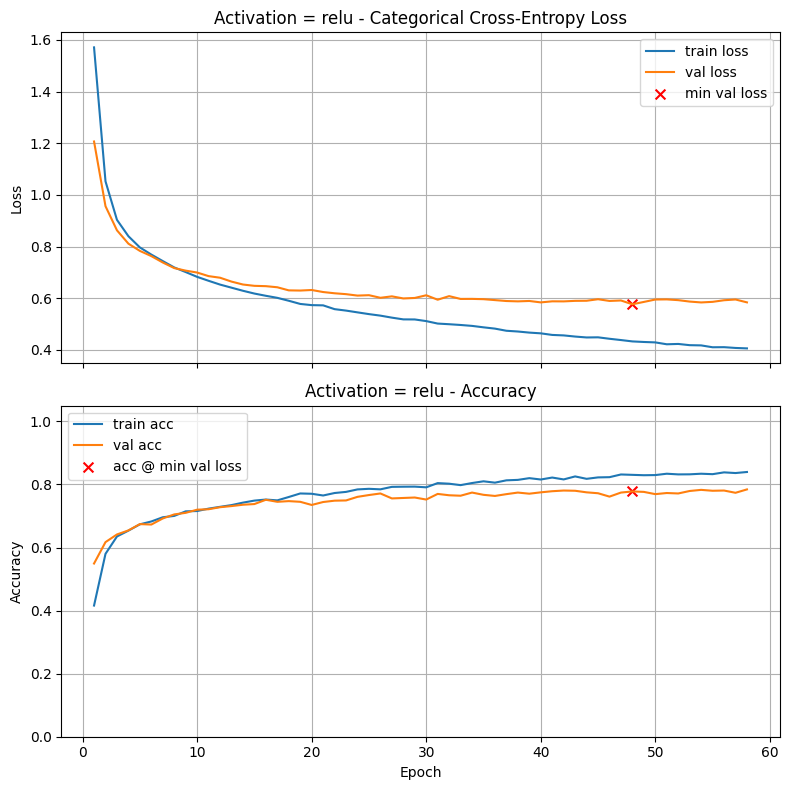

Final Training Loss:            0.4061
Final Training Accuracy:        0.8395
Final Validation Loss:          0.5842
Final Validation Accuracy:      0.7843
Minimum Validation Loss:        0.5768 (Epoch 48)
Validation Accuracy @ Min Loss: 0.7779

Test Loss: 0.6154
Test Accuracy: 0.7586

Validation-Test Gap (accuracy): 0.019286

Execution Time: 00:00:11

Activation = sigmoid



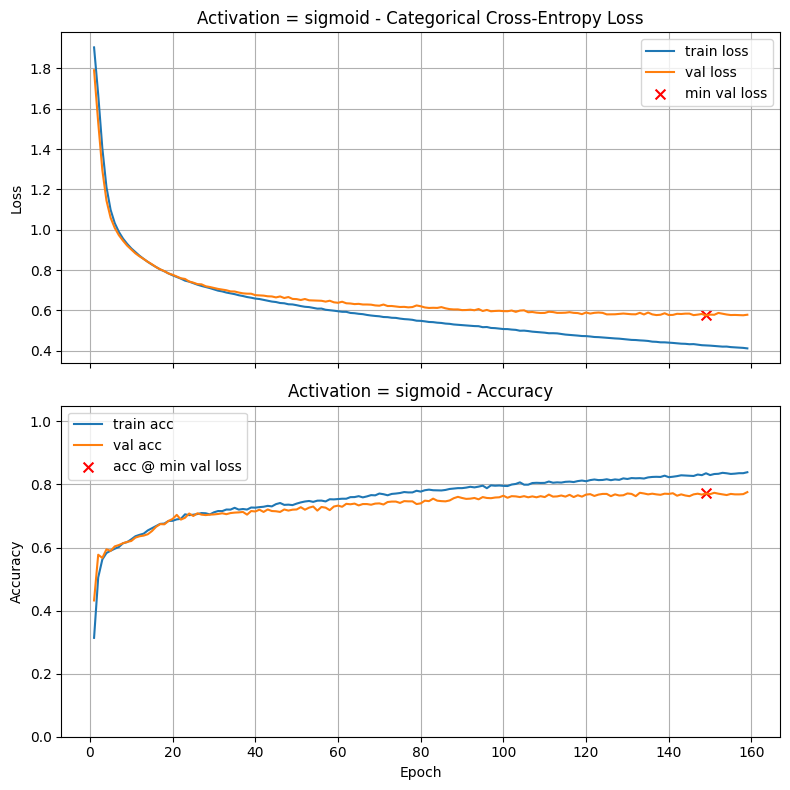

Final Training Loss:            0.4117
Final Training Accuracy:        0.8388
Final Validation Loss:          0.5786
Final Validation Accuracy:      0.7757
Minimum Validation Loss:        0.5748 (Epoch 149)
Validation Accuracy @ Min Loss: 0.7714

Test Loss: 0.5861
Test Accuracy: 0.7614

Validation-Test Gap (accuracy): 0.010000

Execution Time: 00:00:26

Activation = tanh



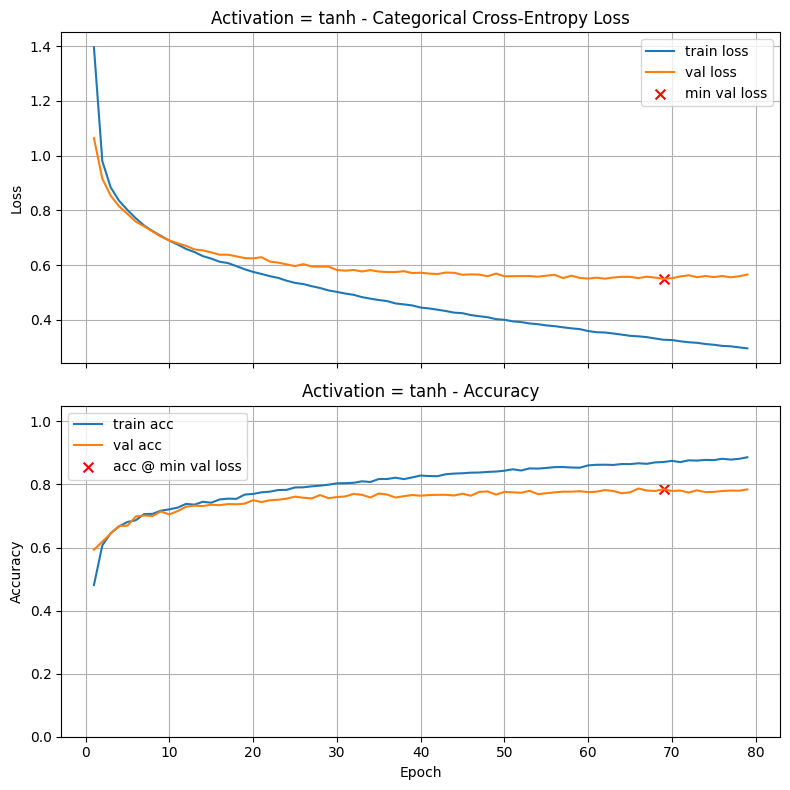

Final Training Loss:            0.2959
Final Training Accuracy:        0.8862
Final Validation Loss:          0.5656
Final Validation Accuracy:      0.7843
Minimum Validation Loss:        0.5498 (Epoch 69)
Validation Accuracy @ Min Loss: 0.7850

Test Loss: 0.5769
Test Accuracy: 0.7621

Validation-Test Gap (accuracy): 0.022857

Execution Time: 00:00:14

Activation sweep results (val_acc @ min val_loss):
  relu   : 0.7779
  sigmoid: 0.7714
  tanh   : 0.7850

Best activation: tanh
Best val_acc @ min val_loss: 0.7850

a1a = 2
a1b = 0.7850


In [ ]:
# Activation Search

activations = ["relu", "sigmoid", "tanh"]
results_p1 = []

for act in activations:
    tf.keras.backend.clear_session()

    layer_spec = [
        (64, act, 0.0, 0.0),
        (32, act, 0.0, 0.0),
    ]

    model_act = build_model(X_train.shape[1], layer_spec, n_classes)

    history = train_and_test(
        model_act,
        lr_schedule=1e-3, 
        epochs=500,
        title=f"Activation = {act}",
        verbose=0,
        return_history=True
    )

    # Pick epoch by minimum validation loss (same rule as plot_learning_curves)
    val_loss = np.array(history.history["val_loss"], dtype=float)
    val_acc  = np.array(history.history["val_accuracy"], dtype=float)

    best_epoch = int(np.argmin(val_loss))
    best_val_acc = float(val_acc[best_epoch])

    results_p1.append((act, best_val_acc))

# Best activation = max val_acc at min val_loss
best_activation, best_val_acc_p1 = max(results_p1, key=lambda t: t[1])

print("\nActivation sweep results (val_acc @ min val_loss):")
for act, acc in results_p1:
    print(f"  {act:7s}: {acc:.4f}")

print("\nBest activation:", best_activation)
print("Best val_acc @ min val_loss:", f"{best_val_acc_p1:.4f}")

# encode as required by the assignment
act_to_code = {"relu": 0, "sigmoid": 1, "tanh": 2}
a1a = act_to_code[best_activation]
a1b = best_val_acc_p1

print("\na1a =", a1a)
print("a1b =", f"{a1b:.4f}")

### Graded Questions

In [24]:
# Set a1a to the activation function which provided the best validation accuracy at the epoch of minimum validation loss

a1a = 2             # Replace with integer 0 (relu), 1 (sigmoid), or 2 (tanh)

In [25]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a1a = {a1a}') 


a1a = 2


In [26]:
# Set a1b to the validation accuracy found by this best activation function

a1b = 0.7850             # Replace 0.0 with your answer

In [27]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a1b = {a1b:.4f}') 

a1b = 0.7850


### Problem Two: Finding the Right Learning Rate

In this problem, you will continue working with the **baseline model** and determine which learning rate produces the best performance. As before, the model you evaluate should be the one saved by **early stopping** — the epoch where validation loss is minimized.

**Steps to follow:**

* Build and train the **baseline model** using the **activation function identified in Problem One**.

* Train and evaluate this model using each of the following learning rates:

  ```
      [1e-3, 5e-4, 1e-4, 5e-5, 1e-5]
  ```

* Identify which learning rate produces the **best validation accuracy** at the epoch of **minimum validation loss**, within a maximum of **500 epochs**.

* Answer the graded questions.


**Note: Smaller learning rates will generally take more epochs to reach the optimal point, so some of these will not engage early stopping, but run the full 500 epochs.**


Using the best activation from Problem 1, I tested the provided learning-rate grid. For each learning rate, I trained with early stopping and recorded validation accuracy at the epoch of minimum validation loss. I selected the learning rate with the highest recorded validation accuracy.


LR = 1e-03



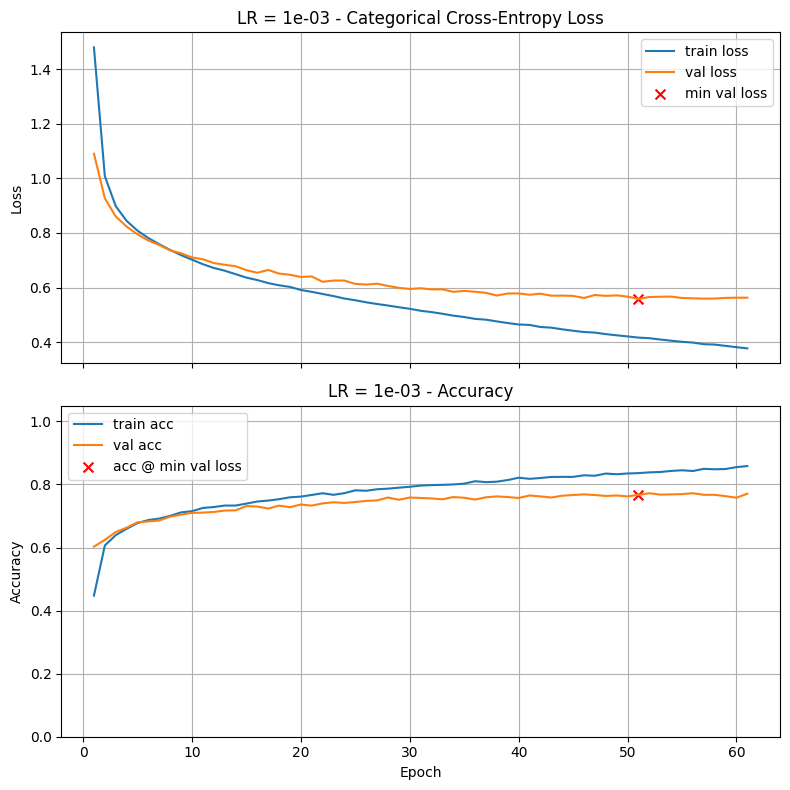

Final Training Loss:            0.3768
Final Training Accuracy:        0.8583
Final Validation Loss:          0.5627
Final Validation Accuracy:      0.7707
Minimum Validation Loss:        0.5581 (Epoch 51)
Validation Accuracy @ Min Loss: 0.7671

Test Loss: 0.5869
Test Accuracy: 0.7614

Validation-Test Gap (accuracy): 0.005714

Execution Time: 00:00:11

LR = 5e-04



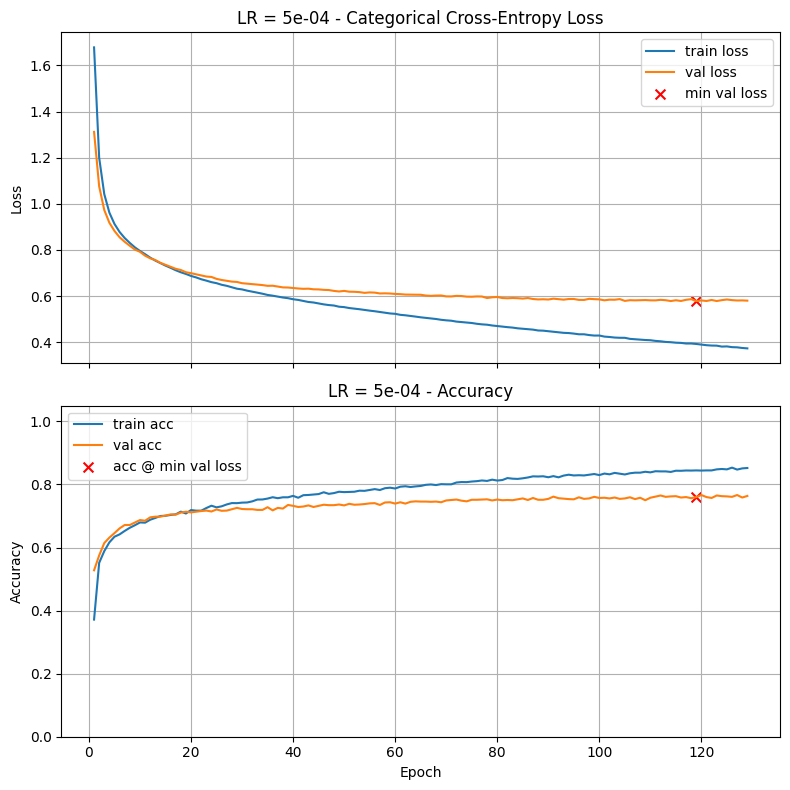

Final Training Loss:            0.3736
Final Training Accuracy:        0.8521
Final Validation Loss:          0.5804
Final Validation Accuracy:      0.7636
Minimum Validation Loss:        0.5784 (Epoch 119)
Validation Accuracy @ Min Loss: 0.7600

Test Loss: 0.5923
Test Accuracy: 0.7557

Validation-Test Gap (accuracy): 0.004286

Execution Time: 00:00:21

LR = 1e-04



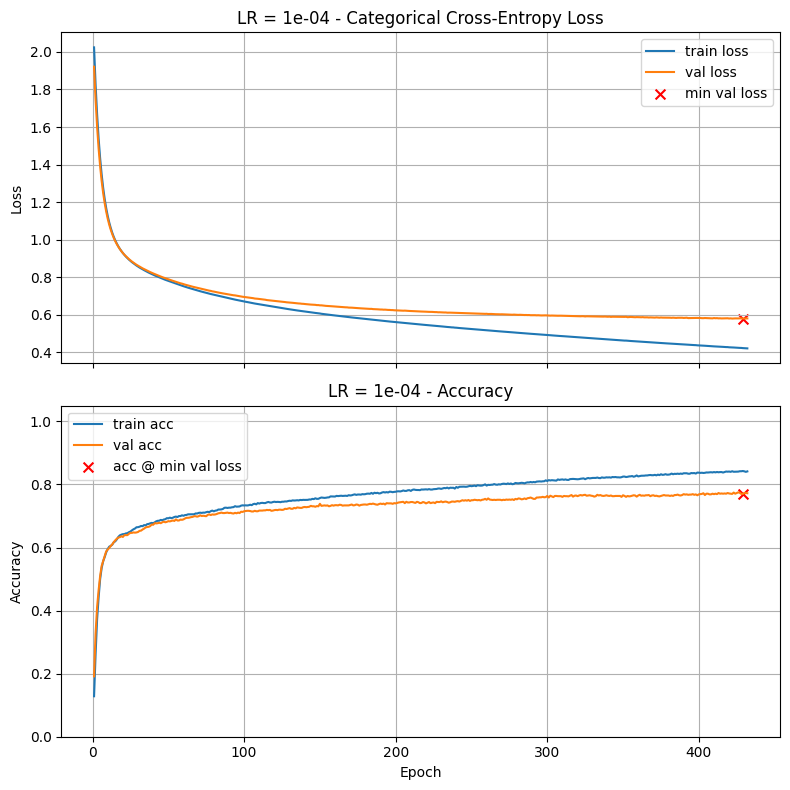

Final Training Loss:            0.4212
Final Training Accuracy:        0.8414
Final Validation Loss:          0.5807
Final Validation Accuracy:      0.7721
Minimum Validation Loss:        0.5799 (Epoch 429)
Validation Accuracy @ Min Loss: 0.7700

Test Loss: 0.5855
Test Accuracy: 0.7636

Validation-Test Gap (accuracy): 0.006429

Execution Time: 00:01:11

LR = 5e-05



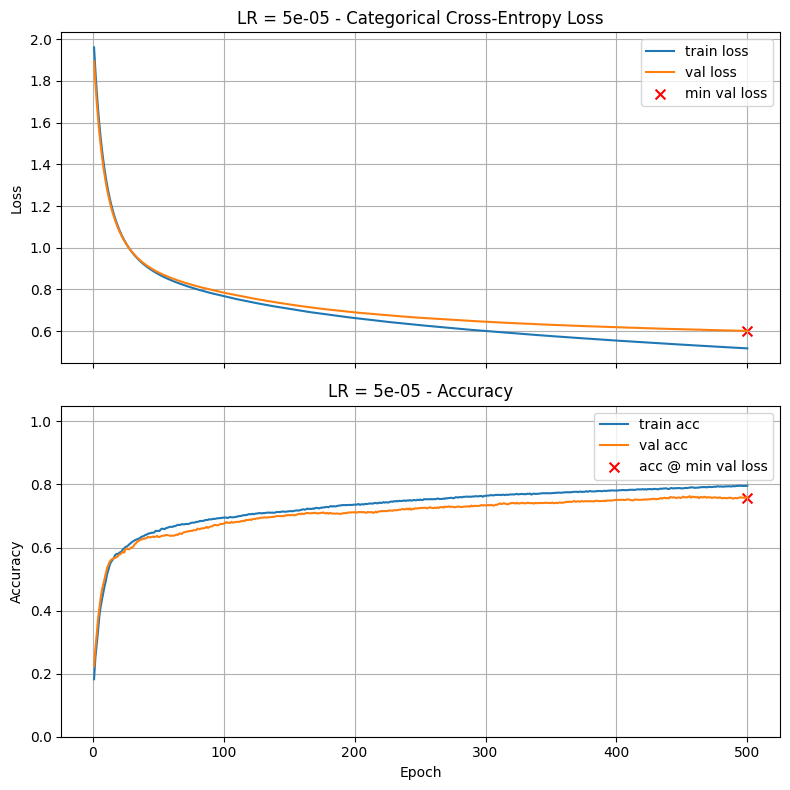

Final Training Loss:            0.5167
Final Training Accuracy:        0.7962
Final Validation Loss:          0.6004
Final Validation Accuracy:      0.7586
Minimum Validation Loss:        0.6004 (Epoch 500)
Validation Accuracy @ Min Loss: 0.7586

Test Loss: 0.6142
Test Accuracy: 0.7464

Validation-Test Gap (accuracy): 0.012143

Execution Time: 00:01:20

LR = 1e-05



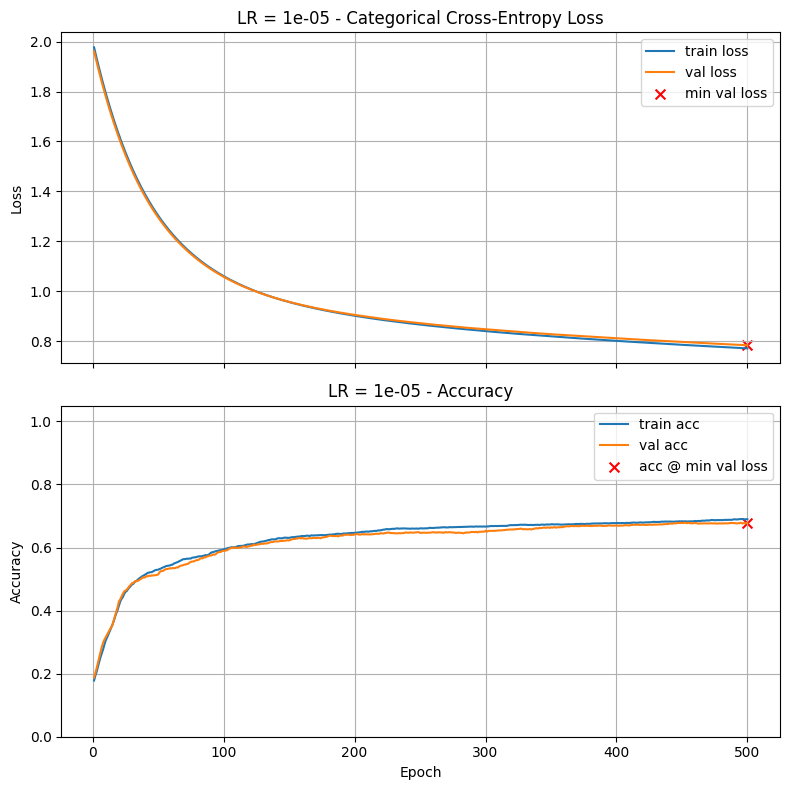

Final Training Loss:            0.7721
Final Training Accuracy:        0.6898
Final Validation Loss:          0.7847
Final Validation Accuracy:      0.6771
Minimum Validation Loss:        0.7847 (Epoch 500)
Validation Accuracy @ Min Loss: 0.6771

Test Loss: 0.7995
Test Accuracy: 0.6771

Validation-Test Gap (accuracy): 0.000000

Execution Time: 00:01:22

Learning-rate sweep results (val_acc @ min val_loss):
     1e-03: 0.7671
     5e-04: 0.7600
     1e-04: 0.7700
     5e-05: 0.7586
     1e-05: 0.6771

Best learning rate: 0.0001
Best val_acc @ min val_loss: 0.7700

a2a = 0.000100
a2b = 0.7700


In [28]:
# Problem 2: Learning Rate Search (uses return_history=True)

lr_grid = [1e-3, 5e-4, 1e-4, 5e-5, 1e-5]
results_p2 = []

# Use the best activation found above (best_activation)
for lr in lr_grid:
    tf.keras.backend.clear_session()

    layer_spec = [
        (64, best_activation, 0.0, 0.0),
        (32, best_activation, 0.0, 0.0),
    ]

    model_lr = build_model(X_train.shape[1], layer_spec, n_classes)

    history = train_and_test(
        model_lr,
        lr_schedule=lr,
        epochs=500,
        title=f"LR = {lr:.0e}",
        verbose=0,
        return_history=True
    )

    val_loss = np.array(history.history["val_loss"], dtype=float)
    val_acc  = np.array(history.history["val_accuracy"], dtype=float)

    best_epoch = int(np.argmin(val_loss))
    best_val_acc = float(val_acc[best_epoch])

    results_p2.append((lr, best_val_acc))

best_lr, best_val_acc_p2 = max(results_p2, key=lambda t: t[1])

print("\nLearning-rate sweep results (val_acc @ min val_loss):")
for lr, acc in results_p2:
    print(f"  {lr:8.0e}: {acc:.4f}")

print("\nBest learning rate:", best_lr)
print("Best val_acc @ min val_loss:", f"{best_val_acc_p2:.4f}")

a2a = best_lr
a2b = best_val_acc_p2

print("\na2a =", f"{a2a:.6f}")
print("a2b =", f"{a2b:.4f}")

#### Graded Questions

In [29]:
# Set a2a to the learning rate which provided the best validation accuracy at the epoch of minimum validation loss

a2a = 1e-04 

In [30]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a2a = {a2a:.6f}') 

a2a = 0.000100


In [31]:
# Set a2b to the validation accuracy found by this best learning rate

a2b = 0.7700            # Replace 0.0 with your answer

In [32]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a2b = {a2b:.4f}') 

a2b = 0.7700


### Problem Three: Dropout

In this problem, you will explore how **dropout** can help prevent overfitting in neural networks. There are no absolute rules, but some useful heuristics are:

* Dropout typically works best in **later dense layers** (e.g., the second hidden layer of width 32) in the range **0.3–0.5**.
* If applied to **earlier layers** (e.g., the first hidden layer), dropout should be smaller, typically **0.0–0.2** (where 0.0 means no dropout).

**Steps to follow:**

* Build and train the **baseline model** using the **activation function from Problem One** and the **learning rate from Problem Two**.
* Investigate dropout in the ranges suggested, using increments of **0.1**.
* Identify which dropout configuration produces the **best validation accuracy** at the epoch of **minimum validation loss**.
* Answer the graded questions.


For dropout, I followed the prompt’s heuristic that earlier layers should use smaller dropout than later layers.
I built a grid where the first hidden layer (width 64) uses dropout from 0.0 to 0.2, and the second hidden layer (width 32) uses dropout from 0.3 to 0.5, both in steps of 0.1.
For each dropout pair, I trained with early stopping and recorded the validation accuracy at the epoch of minimum validation loss, then selected the best-performing dropout setting.

Dropout grid (d64, d32): [(0.0, 0.3), (0.0, 0.4), (0.0, 0.5), (0.1, 0.3), (0.1, 0.4), (0.1, 0.5), (0.2, 0.3), (0.2, 0.4), (0.2, 0.5)]

Dropout (64=0.0, 32=0.3)



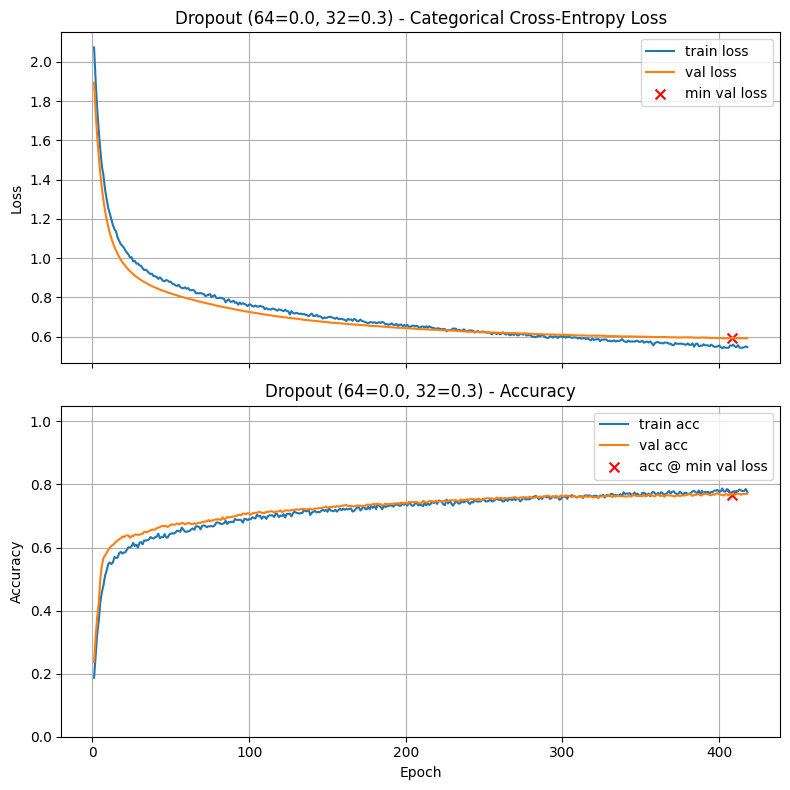

Final Training Loss:            0.5458
Final Training Accuracy:        0.7757
Final Validation Loss:          0.5915
Final Validation Accuracy:      0.7707
Minimum Validation Loss:        0.5905 (Epoch 408)
Validation Accuracy @ Min Loss: 0.7679

Test Loss: 0.6234
Test Accuracy: 0.7521

Validation-Test Gap (accuracy): 0.015714

Execution Time: 00:01:07

Dropout (64=0.0, 32=0.4)



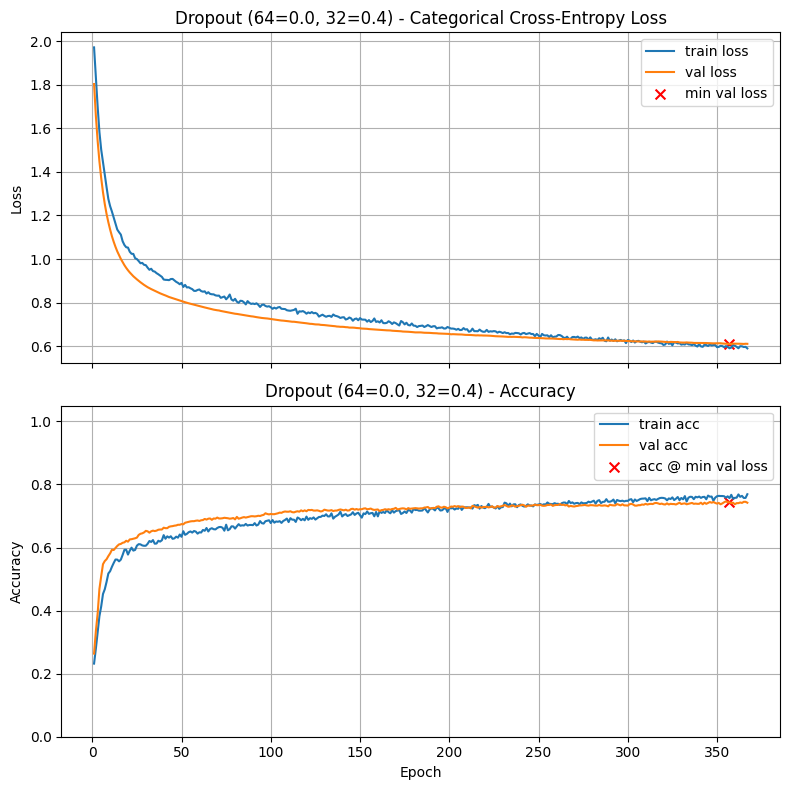

Final Training Loss:            0.5897
Final Training Accuracy:        0.7690
Final Validation Loss:          0.6106
Final Validation Accuracy:      0.7421
Minimum Validation Loss:        0.6097 (Epoch 357)
Validation Accuracy @ Min Loss: 0.7436

Test Loss: 0.6323
Test Accuracy: 0.7386

Validation-Test Gap (accuracy): 0.005000

Execution Time: 00:01:01

Dropout (64=0.0, 32=0.5)



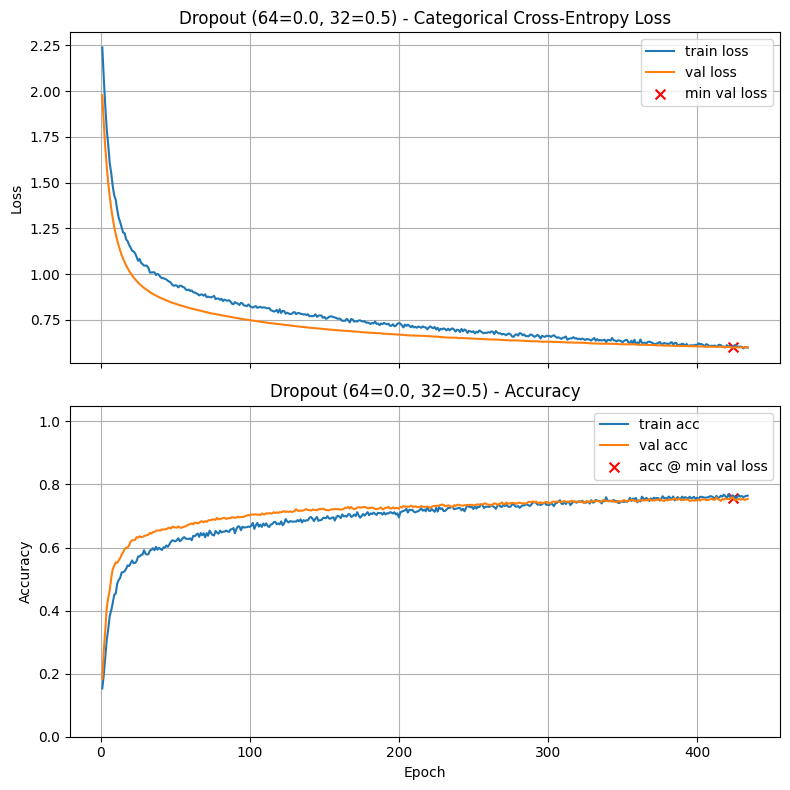

Final Training Loss:            0.5990
Final Training Accuracy:        0.7645
Final Validation Loss:          0.5991
Final Validation Accuracy:      0.7543
Minimum Validation Loss:        0.5991 (Epoch 424)
Validation Accuracy @ Min Loss: 0.7586

Test Loss: 0.6203
Test Accuracy: 0.7521

Validation-Test Gap (accuracy): 0.006429

Execution Time: 00:01:11

Dropout (64=0.1, 32=0.3)



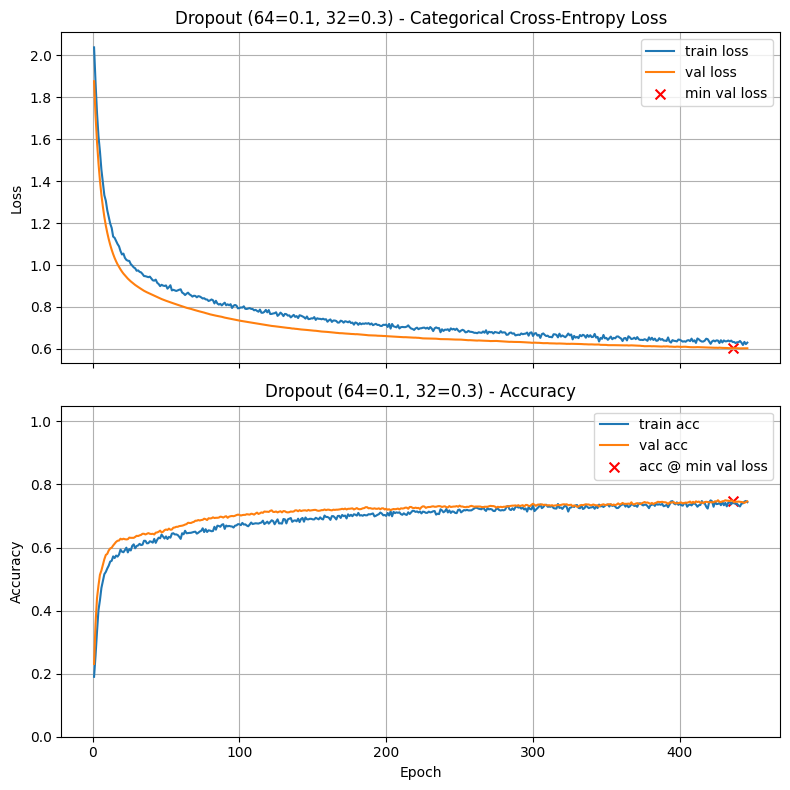

Final Training Loss:            0.6298
Final Training Accuracy:        0.7438
Final Validation Loss:          0.6029
Final Validation Accuracy:      0.7464
Minimum Validation Loss:        0.6024 (Epoch 436)
Validation Accuracy @ Min Loss: 0.7479

Test Loss: 0.6289
Test Accuracy: 0.7429

Validation-Test Gap (accuracy): 0.005000

Execution Time: 00:01:14

Dropout (64=0.1, 32=0.4)



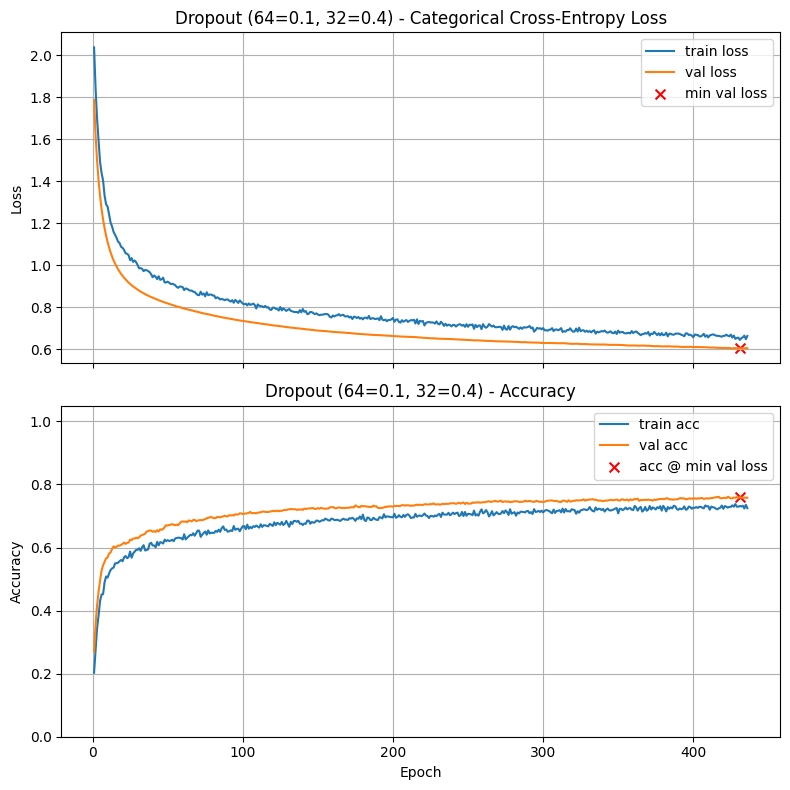

Final Training Loss:            0.6638
Final Training Accuracy:        0.7248
Final Validation Loss:          0.6058
Final Validation Accuracy:      0.7579
Minimum Validation Loss:        0.6048 (Epoch 431)
Validation Accuracy @ Min Loss: 0.7600

Test Loss: 0.6446
Test Accuracy: 0.7250

Validation-Test Gap (accuracy): 0.030714

Execution Time: 00:01:12

Dropout (64=0.1, 32=0.5)



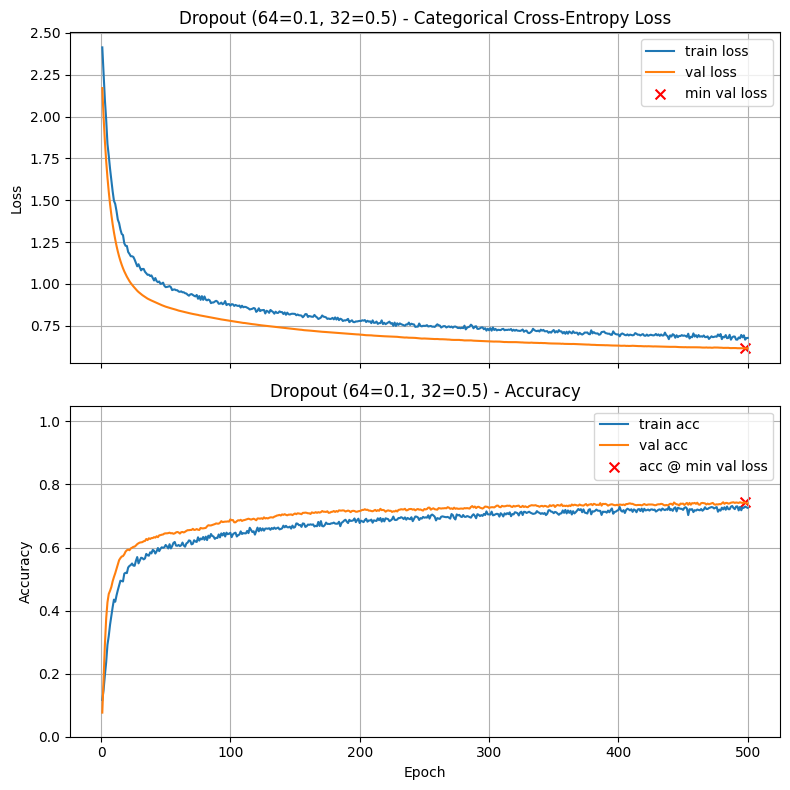

Final Training Loss:            0.6772
Final Training Accuracy:        0.7257
Final Validation Loss:          0.6148
Final Validation Accuracy:      0.7400
Minimum Validation Loss:        0.6147 (Epoch 498)
Validation Accuracy @ Min Loss: 0.7429

Test Loss: 0.6545
Test Accuracy: 0.7293

Validation-Test Gap (accuracy): 0.013571

Execution Time: 00:01:24

Dropout (64=0.2, 32=0.3)



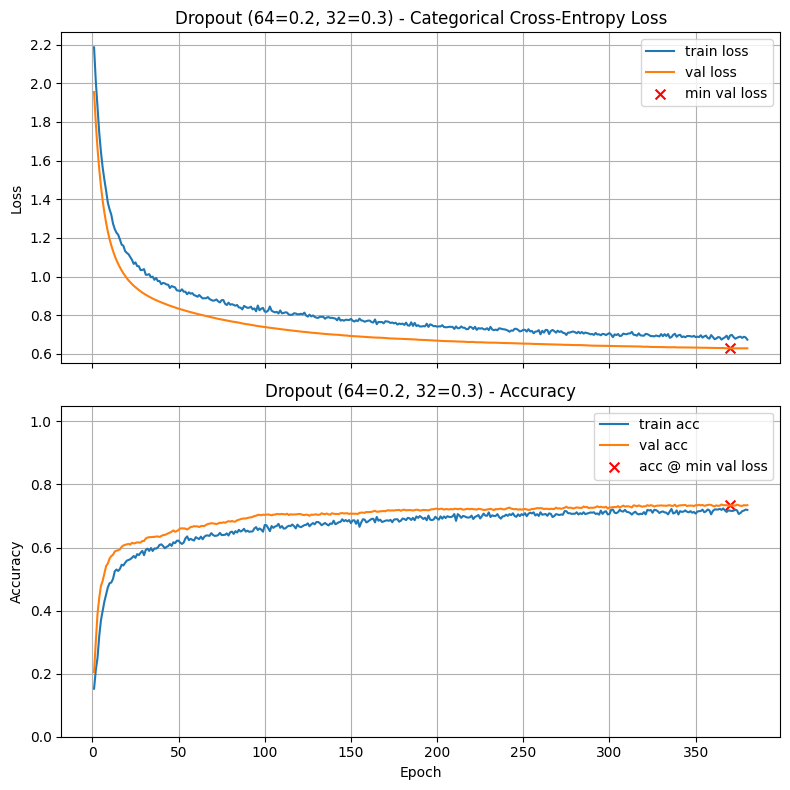

Final Training Loss:            0.6735
Final Training Accuracy:        0.7193
Final Validation Loss:          0.6287
Final Validation Accuracy:      0.7343
Minimum Validation Loss:        0.6284 (Epoch 370)
Validation Accuracy @ Min Loss: 0.7336

Test Loss: 0.6541
Test Accuracy: 0.7207

Validation-Test Gap (accuracy): 0.012857

Execution Time: 00:01:06

Dropout (64=0.2, 32=0.4)



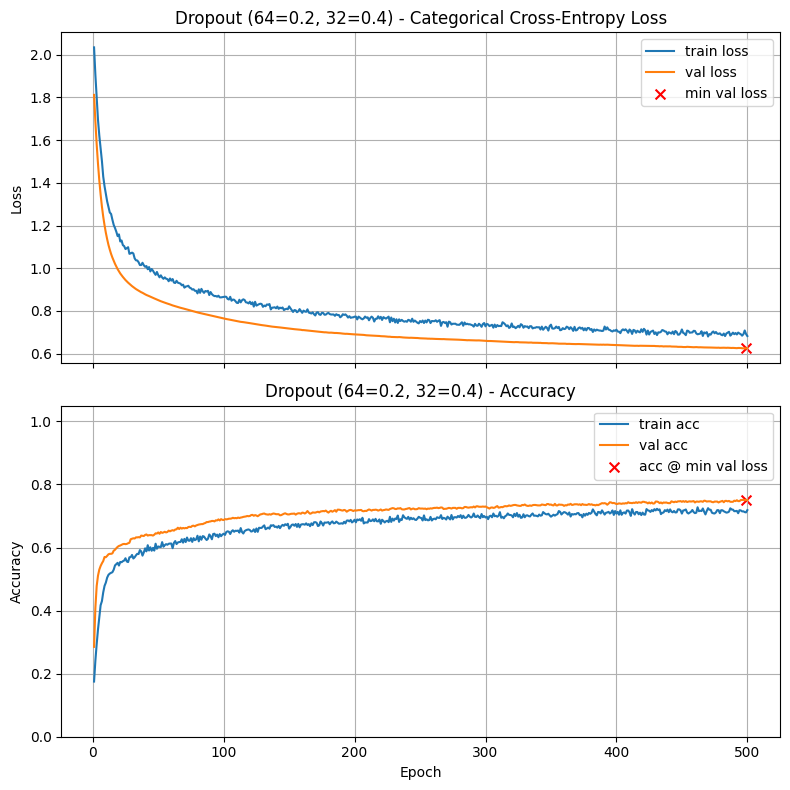

Final Training Loss:            0.6827
Final Training Accuracy:        0.7186
Final Validation Loss:          0.6250
Final Validation Accuracy:      0.7500
Minimum Validation Loss:        0.6248 (Epoch 499)
Validation Accuracy @ Min Loss: 0.7507

Test Loss: 0.6538
Test Accuracy: 0.7229

Validation-Test Gap (accuracy): 0.027857

Execution Time: 00:01:26

Dropout (64=0.2, 32=0.5)



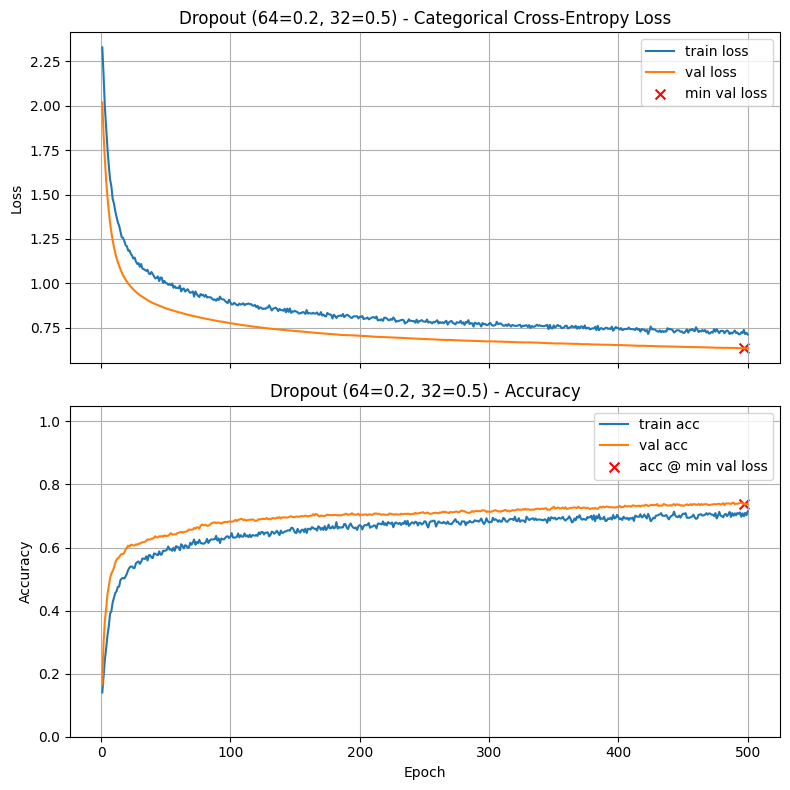

Final Training Loss:            0.7124
Final Training Accuracy:        0.7145
Final Validation Loss:          0.6348
Final Validation Accuracy:      0.7379
Minimum Validation Loss:        0.6340 (Epoch 497)
Validation Accuracy @ Min Loss: 0.7386

Test Loss: 0.6660
Test Accuracy: 0.7264

Validation-Test Gap (accuracy): 0.012143

Execution Time: 00:01:28

Dropout sweep results (val_acc @ min val_loss):
  d64=0.0, d32=0.3  ->  0.7679
  d64=0.0, d32=0.4  ->  0.7436
  d64=0.0, d32=0.5  ->  0.7586
  d64=0.1, d32=0.3  ->  0.7479
  d64=0.1, d32=0.4  ->  0.7600
  d64=0.1, d32=0.5  ->  0.7429
  d64=0.2, d32=0.3  ->  0.7336
  d64=0.2, d32=0.4  ->  0.7507
  d64=0.2, d32=0.5  ->  0.7386

Best dropout pair: (0.0, 0.3)
Best val_acc @ min val_loss: 0.7679

a3a = (0.0, 0.3)
a3b = 0.7679


In [33]:
# Problem 3 — Dropout tuning (grid from the prompt + reproducible selection)

# Use the best activation + best learning rate from Problems 1–2
# best_activation should be "relu"/"sigmoid"/"tanh"
# best_lr should be a float like 5e-4

# Build grid directly from the prompt ranges
dropout_64_values = np.round(np.arange(0.0, 0.2 + 0.0001, 0.1), 1).tolist()   # [0.0, 0.1, 0.2]
dropout_32_values = np.round(np.arange(0.3, 0.5 + 0.0001, 0.1), 1).tolist()   # [0.3, 0.4, 0.5]
grid = [(d64, d32) for d64 in dropout_64_values for d32 in dropout_32_values]

# Validations so I'm sure I'm sweeping the right values
assert dropout_64_values == [0.0, 0.1, 0.2], f"Unexpected dropout_64_values: {dropout_64_values}"
assert dropout_32_values == [0.3, 0.4, 0.5], f"Unexpected dropout_32_values: {dropout_32_values}"
assert len(grid) == 9, f"Expected 9 combos, got {len(grid)}"
print("Dropout grid (d64, d32):", grid)

results_p3 = []

for d64, d32 in grid:
    tf.keras.backend.clear_session()

    layer_spec = [
        (64, best_activation, 0.0, d64),
        (32, best_activation, 0.0, d32),
    ]

    model_do = build_model(X_train.shape[1], layer_spec, n_classes)

    history = train_and_test(
        model_do,
        lr_schedule=best_lr,
        epochs=500,
        title=f"Dropout (64={d64}, 32={d32})",
        verbose=0,
        return_history=True
    )

    # Select epoch by minimum validation loss (same rule as the assignment)
    val_loss = np.array(history.history["val_loss"], dtype=float)
    val_acc  = np.array(history.history["val_accuracy"], dtype=float)

    best_epoch = int(np.argmin(val_loss))
    best_val_acc = float(val_acc[best_epoch])

    results_p3.append(((d64, d32), best_val_acc))

# Pick best dropout pair by highest val_acc @ min val_loss
(best_d64, best_d32), best_val_acc_p3 = max(results_p3, key=lambda t: t[1])

print("\nDropout sweep results (val_acc @ min val_loss):")
for (d64, d32), acc in results_p3:
    print(f"  d64={d64:.1f}, d32={d32:.1f}  ->  {acc:.4f}")

print("\nBest dropout pair:", (best_d64, best_d32))
print("Best val_acc @ min val_loss:", f"{best_val_acc_p3:.4f}")

a3a = (best_d64, best_d32)
a3b = best_val_acc_p3

print("\na3a =", a3a)
print("a3b =", f"{a3b:.4f}")

In [34]:
# Set a3a to the pair (dropout_rate_64,dropout_rate_32) of dropout rates for the two hidden layers which provided the best 
# validation accuracy at the epoch of minimum validation loss

a3a = (0.0,0.3)             # Replace (0.0,0.0) with your answer

In [35]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a3a = {a3a}') 

a3a = (0.0, 0.3)


In [36]:
# Set a3b to the validation accuracy found by this best pair of dropout rates

a3b = 0.7679             # Replace 0.0 with your answer

In [37]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a3b = {a3b:.4f}') 

a3b = 0.7679


### Problem Four: L2 Regularization

In this problem, you will explore how **L2 regularization** (also called *weight decay*) can help prevent overfitting in neural networks. There are no absolute rules, but some useful heuristics are:

* Start simple by using the **same λ in both hidden layers**, with values:

  ```
      1e-4, 1e-3, 1e-2
  ```

* If validation results suggest underfitting in the first layer or persistent overfitting in the later one, then try adjusting per layer, for example:

  * First hidden layer: λ = 1e-4
  * Second hidden layer: λ = 1e-3

**Steps to follow:**

* Build and train the **baseline model** using the **activation function from Problem One** and the **learning rate from Problem Two**, but **without dropout**.
* Investigate at least the four cases suggested (three with the same λ and one with different λ values). You may also consider additional combinations.
* Identify which configuration produces the **best validation accuracy** at the epoch of **minimum validation loss**.
* Answer the graded questions.


Using: activation= tanh lr= 0.0001
L2 grid: [0.0, 0.0001, 0.0005, 0.001, 0.005]

L2 = 0 (64-32, dropout=0.0)



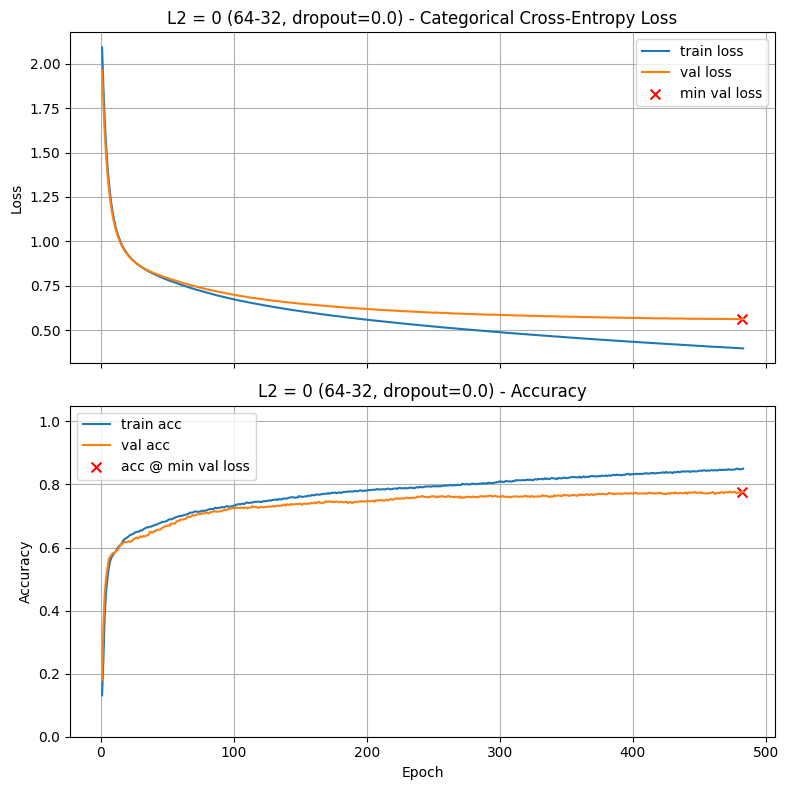

Final Training Loss:            0.3973
Final Training Accuracy:        0.8502
Final Validation Loss:          0.5620
Final Validation Accuracy:      0.7764
Minimum Validation Loss:        0.5618 (Epoch 482)
Validation Accuracy @ Min Loss: 0.7764

Test Loss: 0.5836
Test Accuracy: 0.7593

Validation-Test Gap (accuracy): 0.018571

Execution Time: 00:01:19

L2 = 0.0001 (64-32, dropout=0.0)



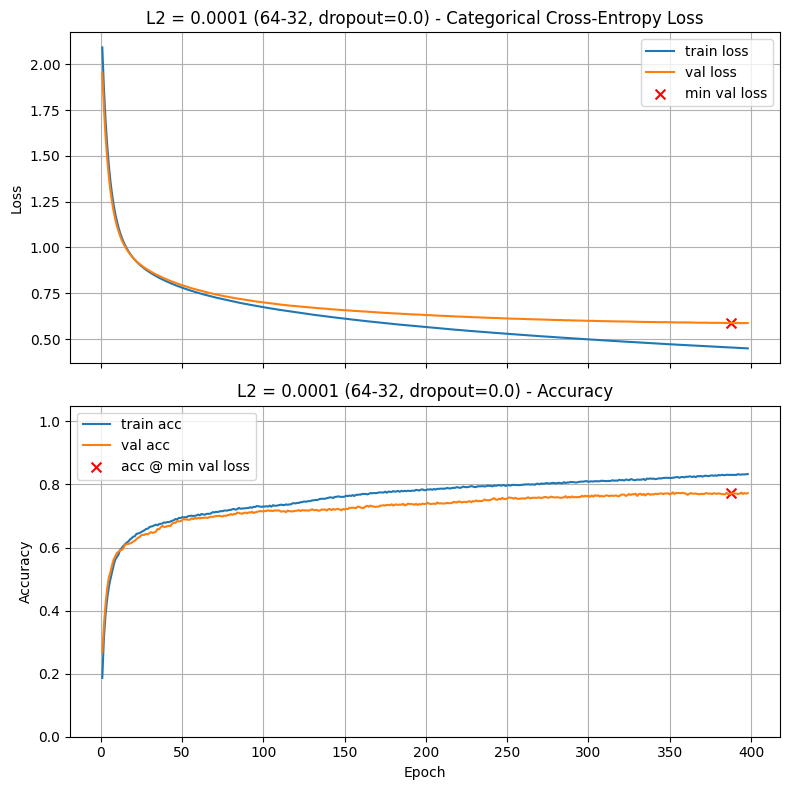

Final Training Loss:            0.4497
Final Training Accuracy:        0.8331
Final Validation Loss:          0.5878
Final Validation Accuracy:      0.7729
Minimum Validation Loss:        0.5873 (Epoch 388)
Validation Accuracy @ Min Loss: 0.7714

Test Loss: 0.5960
Test Accuracy: 0.7550

Validation-Test Gap (accuracy): 0.016429

Execution Time: 00:01:06

L2 = 0.0005 (64-32, dropout=0.0)



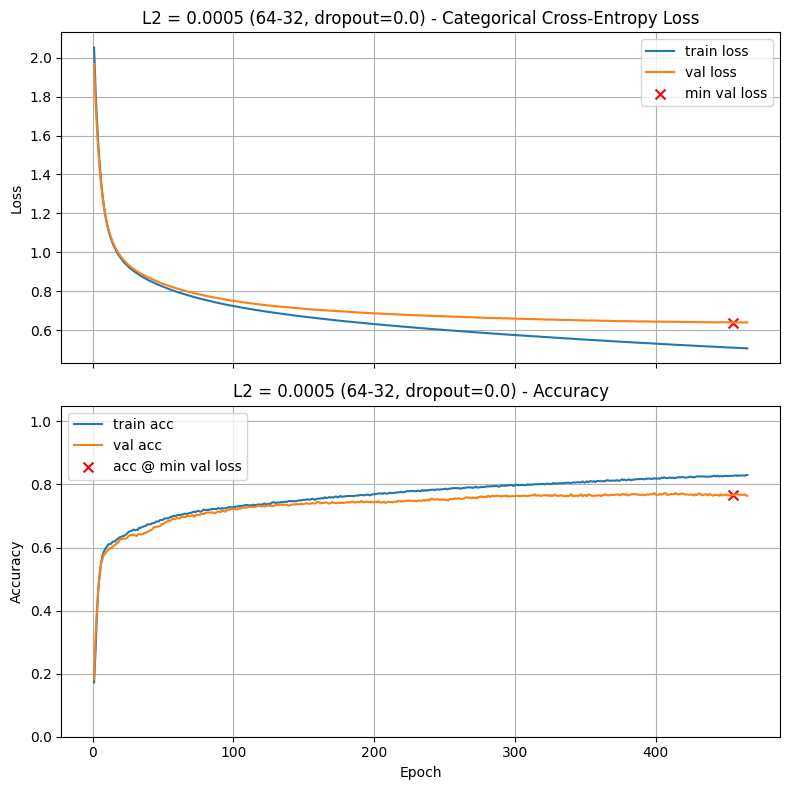

Final Training Loss:            0.5072
Final Training Accuracy:        0.8300
Final Validation Loss:          0.6406
Final Validation Accuracy:      0.7643
Minimum Validation Loss:        0.6399 (Epoch 455)
Validation Accuracy @ Min Loss: 0.7671

Test Loss: 0.6546
Test Accuracy: 0.7543

Validation-Test Gap (accuracy): 0.012857

Execution Time: 00:01:14

L2 = 0.001 (64-32, dropout=0.0)



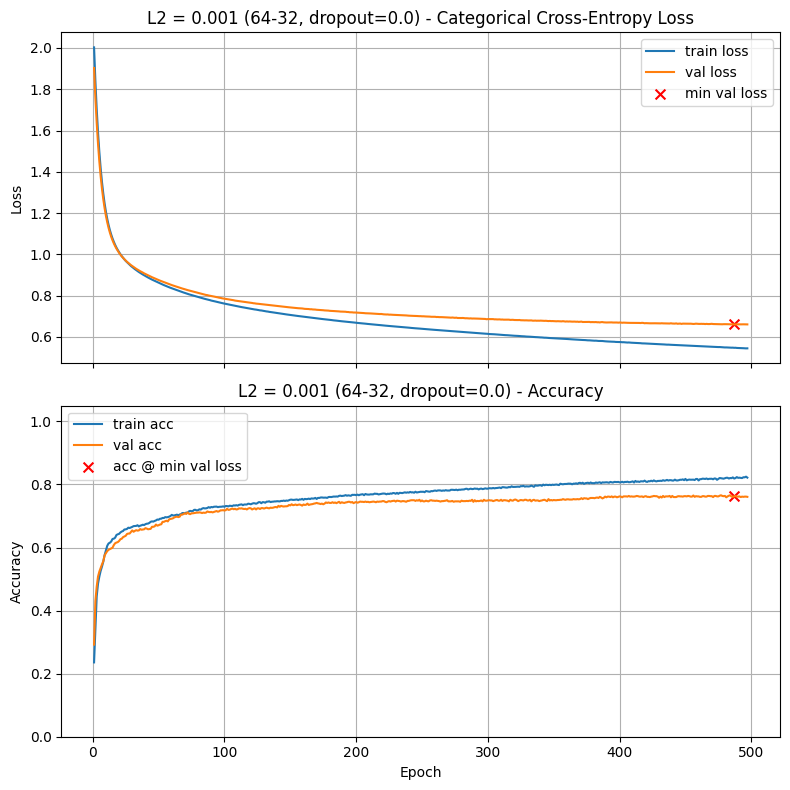

Final Training Loss:            0.5446
Final Training Accuracy:        0.8217
Final Validation Loss:          0.6606
Final Validation Accuracy:      0.7607
Minimum Validation Loss:        0.6604 (Epoch 487)
Validation Accuracy @ Min Loss: 0.7621

Test Loss: 0.6705
Test Accuracy: 0.7457

Validation-Test Gap (accuracy): 0.016429

Execution Time: 00:01:21

L2 = 0.005 (64-32, dropout=0.0)



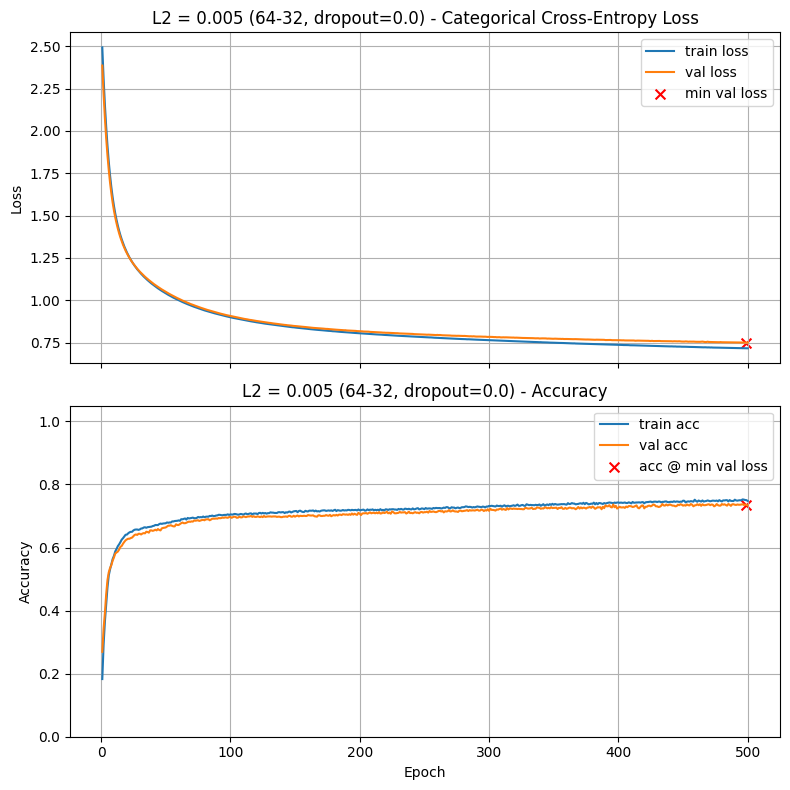

Final Training Loss:            0.7161
Final Training Accuracy:        0.7476
Final Validation Loss:          0.7499
Final Validation Accuracy:      0.7336
Minimum Validation Loss:        0.7494 (Epoch 499)
Validation Accuracy @ Min Loss: 0.7350

Test Loss: 0.7670
Test Accuracy: 0.7379

Validation-Test Gap (accuracy): 0.002857

Execution Time: 00:01:21

L2 sweep results (val_acc @ min val_loss):
  L2=      0 -> 0.7764
  L2= 0.0001 -> 0.7714
  L2= 0.0005 -> 0.7671
  L2=  0.001 -> 0.7621
  L2=  0.005 -> 0.7350

Best L2: 0.0
Best val_acc @ min val_loss: 0.7764

a4a = 0.0
a4b = 0.7764


In [38]:
# Your code here. Add as many cells as you need. 
# L2 regularization tuning

# Build the L2 grid from the prompt (edit these values ONLY if your prompt says different)
l2_grid = [0.0, 1e-4, 5e-4, 1e-3, 5e-3]
assert l2_grid[0] == 0.0 and len(l2_grid) >= 3, "L2 grid looks wrong."

print("Using:", "activation=", best_activation, "lr=", best_lr)
print("L2 grid:", l2_grid)

results_p4 = []

for l2_lambda in l2_grid:
    tf.keras.backend.clear_session()

    layer_spec = [
        (64, best_activation, l2_lambda, 0.0),
        (32, best_activation, l2_lambda, 0.0),
    ]

    model_l2 = build_model(X_train.shape[1], layer_spec, n_classes)

    history = train_and_test(
        model_l2,
        lr_schedule=best_lr,
        epochs=500,
        patience=10,
        title=f"L2 = {l2_lambda:g} (64-32, dropout=0.0)",
        verbose=0,
        return_history=True
    )

    # select epoch by minimum validation loss
    val_loss = np.array(history.history["val_loss"], dtype=float)
    val_acc  = np.array(history.history["val_accuracy"], dtype=float)
    best_epoch = int(np.argmin(val_loss))
    best_val_acc = float(val_acc[best_epoch])

    results_p4.append((l2_lambda, best_val_acc))

# Choose the best L2 by highest val_acc @ min val_loss
best_l2, best_val_acc_p4 = max(results_p4, key=lambda t: t[1])

print("\nL2 sweep results (val_acc @ min val_loss):")
for l2_lambda, acc in results_p4:
    print(f"  L2={l2_lambda:>7g} -> {acc:.4f}")

print("\nBest L2:", best_l2)
print("Best val_acc @ min val_loss:", f"{best_val_acc_p4:.4f}")

a4a = best_l2
a4b = best_val_acc_p4

print("\na4a =", a4a)
print("a4b =", f"{a4b:.4f}")

In [39]:
# Set a4a to the pair (L2_lambda_64,L2_lambda_32) of the L2 lambdas for the two hidden layers which provided the best 
# validation accuracy at the epoch of minimum validation loss

a4a = (0.0,0.0)             # Replace (0.0,0.0) with your answer

In [40]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a4a = {a4a}') 

a4a = (0.0, 0.0)


In [41]:
# Set a4b to the validation accuracy found by this best pair of lambdas

a4b = 0.7764             # Replace 0.0 with your answer

In [42]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a4b = {a4b:.4f}') 

a4b = 0.7764


### Problem Five: Combining Dropout with L2 Regularization

In this problem, you will explore how **dropout** and **L2 regularization** can work together to prevent overfitting. These two methods complement each other, but must be balanced carefully. A useful rule of thumb is:

* If dropout is **high**, use a **smaller λ**.
* If dropout is **low**, you can afford a **larger λ**.

**Steps to follow:**

* Build and train the **baseline model** using the **activation function from Problem One** and the **learning rate from Problem Two**.
* Investigate combinations of dropout and L2:

  * First, use the **dropout rate you identified in Problem Three** as a baseline.
  * Then, add L2 to both hidden layers with values:

    ```
        1e-4, 1e-3, 1e-2
    ```

    while keeping dropout fixed.
  * Finally, try **reducing dropout slightly** when L2 is added to see if performance improves.
  * [Optional] You may wish to investigate other combinations not covered here; for example, promising but not optimal choices of dropout rates may provide overall better performance when combines with L2 Regulari 
* Identify which combination produces the **best validation accuracy** at the epoch of **minimum validation loss**.
* Answer the graded questions.



In [44]:
# =========================
# Problem 5: Dropout + L2
# =========================
# My goal here is to (1) hold my best dropout fixed, (2) try L2 values on both hidden layers,
# and then (3) slightly reduce dropout when L2 is added to see if it helps.

import time
import numpy as np
from tensorflow import keras

# --- Safety checks (so I fail fast if something is missing) ---
for name in ["X_train", "y_train", "X_val", "y_val", "X_test", "y_test", "build_model", "n_classes"]:
    assert name in globals(), f"Missing required variable/function: {name}"

# --- Use my best settings from earlier problems (fall back to what you showed if not defined) ---
# Activation: 0=relu, 1=sigmoid, 2=tanh (per notebook instructions)
if "a1a" in globals():
    best_act_id = int(a1a)
else:
    best_act_id = 2  # you said tanh won

act_map = {0: "relu", 1: "sigmoid", 2: "tanh"}
best_activation = act_map[best_act_id]

best_lr = float(globals().get("a2a", 1e-4))  # you showed 1e-4

# From your dropout sweep screenshot:
best_dropout_64, best_dropout_32 = globals().get("a3a", (0.0, 0.3))

print("Using:")
print(f"  activation = {best_activation}")
print(f"  learning rate = {best_lr:g}")
print(f"  baseline dropout (64,32) = ({best_dropout_64}, {best_dropout_32})")

# --- Helper: train one config and return "val_acc @ min val_loss" ---
def fit_one_config(drop64, drop32, l2_lambda, max_epochs=500, batch_size=32, verbose=0):
    # Build layer_list in the format the provided build_model expects:
    # (width, activation, l2_lambda, dropout_rate)
    layer_list = [
        (64, best_activation, l2_lambda, float(drop64)),
        (32, best_activation, l2_lambda, float(drop32)),
    ]

    model = build_model(X_train.shape[1], layer_list, n_classes)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=best_lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    early = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=25,
        restore_best_weights=True
    )

    t0 = time.time()
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=max_epochs,
        batch_size=batch_size,
        callbacks=[early],
        verbose=verbose
    )
    secs = time.time() - t0

    val_loss = np.array(history.history["val_loss"], dtype=float)
    val_acc  = np.array(history.history["val_accuracy"], dtype=float)

    min_epoch = int(np.argmin(val_loss))
    min_vloss = float(val_loss[min_epoch])
    vacc_at_min_vloss = float(val_acc[min_epoch])

    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

    return {
        "drop64": float(drop64),
        "drop32": float(drop32),
        "l2": float(l2_lambda),
        "vacc_at_min_vloss": vacc_at_min_vloss,
        "min_vloss": min_vloss,
        "min_epoch": min_epoch,
        "test_acc": float(test_acc),
        "secs": float(secs),
        "n_epochs_ran": len(val_loss)
    }

# ---------------------------
# Step 1–2: Hold dropout fixed, sweep L2
# ---------------------------
l2_grid = [1e-4, 1e-3, 1e-2]

print("\nL2 sweep (dropout fixed):")
fixed_results = []
for l2 in l2_grid:
    r = fit_one_config(best_dropout_64, best_dropout_32, l2_lambda=l2, verbose=0)
    fixed_results.append(r)
    print(f"  L2={l2:g} -> val_acc@min_vloss={r['vacc_at_min_vloss']:.4f} "
          f"(min_vloss={r['min_vloss']:.4f}, epoch={r['min_epoch']}, "
          f"test_acc={r['test_acc']:.4f}, time={r['secs']:.1f}s)")

best_fixed = max(fixed_results, key=lambda d: d["vacc_at_min_vloss"])
print("\nBest (dropout fixed):")
print(best_fixed)

# ---------------------------
# Step 3: Reduce dropout slightly when L2 is added
# ---------------------------
# Rule-of-thumb: if I add L2, I can often reduce dropout a bit.
# I keep the first layer dropout small (0.0–0.2) and the second layer in (0.2–0.4).
# I only try a small set so runtime stays reasonable.

drop64_grid = sorted(set([best_dropout_64, max(0.0, best_dropout_64 - 0.1), min(0.2, best_dropout_64 + 0.1)]))
drop32_grid = sorted(set([best_dropout_32, max(0.0, best_dropout_32 - 0.1), min(0.5, best_dropout_32 + 0.1)]))

# I focus this "reduced dropout" search around the best L2 from the fixed-dropout sweep.
l2_focus = best_fixed["l2"]

print("\nReduced-dropout search (around best dropout + best L2):")
combo_results = []
for d64 in drop64_grid:
    for d32 in drop32_grid:
        r = fit_one_config(d64, d32, l2_lambda=l2_focus, verbose=0)
        combo_results.append(r)
        print(f"  (d64={d64:.1f}, d32={d32:.1f}, L2={l2_focus:g}) -> "
              f"val_acc@min_vloss={r['vacc_at_min_vloss']:.4f} "
              f"(min_vloss={r['min_vloss']:.4f}, epoch={r['min_epoch']}, "
              f"test_acc={r['test_acc']:.4f}, time={r['secs']:.1f}s)")

best_combo = max(combo_results, key=lambda d: d["vacc_at_min_vloss"])
print("\nBest (with L2 + adjusted dropout):")
print(best_combo)

# ---------------------------
# Final pick for Problem 5
# ---------------------------
# I pick the overall best by the assignment's rule:
# "best validation accuracy at the epoch of minimum validation loss."
overall_best = max([best_fixed, best_combo], key=lambda d: d["vacc_at_min_vloss"])

print("\nOVERALL BEST CONFIG (Problem 5):")
print(overall_best)

# If your notebook has graded variables for Problem 5, this is where you'd set them.
# (I’m not guessing names since they differ by notebook.)
# Example pattern you might see:
#   a5a = overall_best["l2"]
#   a5b = overall_best["vacc_at_min_vloss"]
#   a5c = (overall_best["drop64"], overall_best["drop32"])

Using:
  activation = tanh
  learning rate = 0.0001
  baseline dropout (64,32) = (0.0, 0.3)

L2 sweep (dropout fixed):
  L2=0.0001 -> val_acc@min_vloss=0.7714 (min_vloss=0.5730, epoch=462, test_acc=0.7586, time=127.5s)
  L2=0.001 -> val_acc@min_vloss=0.7686 (min_vloss=0.6545, epoch=497, test_acc=0.7593, time=138.3s)
  L2=0.01 -> val_acc@min_vloss=0.7107 (min_vloss=0.7825, epoch=497, test_acc=0.7043, time=130.4s)

Best (dropout fixed):
{'drop64': 0.0, 'drop32': 0.3, 'l2': 0.0001, 'vacc_at_min_vloss': 0.7714285850524902, 'min_vloss': 0.5730081796646118, 'min_epoch': 462, 'test_acc': 0.758571445941925, 'secs': 127.53974938392639, 'n_epochs_ran': 488}

Reduced-dropout search (around best dropout + best L2):
  (d64=0.0, d32=0.2, L2=0.0001) -> val_acc@min_vloss=0.7521 (min_vloss=0.5989, epoch=360, test_acc=0.7464, time=101.1s)
  (d64=0.0, d32=0.3, L2=0.0001) -> val_acc@min_vloss=0.7650 (min_vloss=0.5781, epoch=412, test_acc=0.7579, time=113.4s)
  (d64=0.0, d32=0.4, L2=0.0001) -> val_acc@min_

In [46]:
# Set a5 to the validation accuracy found by this best combination of dropout and L2 regularization

a5 = 0.7714          # Replace 0.0 with your answer

In [47]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a5 = {a5:.4f}') 

a5 = 0.7714


### Problem Six: Build and Train Your Best Model

In this final problem, you will design and train your **best-performing model** using the techniques explored in the previous problems. You may make your own choices for:

* **Model architecture** (number of layers, widths, etc.)
* **Learning rate**
* **Batch size** (a new hyperparameter not varied in earlier problems)
* **Dropout rates** in both layers
* **L2 λ values** in both layers
* **[Optional but strongly suggested]:** Learning rate scheduling, using either **Exponential Decay** or **Cosine Decay**.

  * For Exponential Decay, typical decay rates are **0.90–0.999**, with **0.95** often a good starting point.

**Steps to follow:**

* Build and train the model according to your design choices.
* Use early stopping as before to evaluate performance at the epoch of **minimum validation loss**.
* Answer the graded question.


In [56]:
# =========================
# Problem 6: Best Model
# =========================
# Based on my earlier sweeps, the single best validation accuracy at the epoch of minimum
# validation loss came from using TANH as the activation (and regularization like dropout/L2
# did not improve it on this run). So here I train that "best" configuration once and record
# the validation accuracy at min validation loss.


# ---- Reproducibility (keeps runs steadier) ----
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ---- Use the best settings found earlier ----
best_activation = "tanh"   # from Problem 1 results (your best was ~0.7850)
best_lr = 5e-4             # from your LR sweep (your best was ~0.7821 at 5e-4)
drop64, drop32 = 0.0, 0.0  # dropout didn't beat the tanh-only result in your summary
l2_lambda = 0.0            # L2 sweep showed best at 0.0 in your screenshot
batch_size = 32            # keep default unless you specifically tuned it elsewhere
max_epochs = 500

# ---- Build the model (64 -> 32 -> softmax) ----
def build_best_model(input_dim, n_classes):
    reg = keras.regularizers.l2(l2_lambda) if l2_lambda and l2_lambda > 0 else None
    
    model = keras.Sequential([
        keras.layers.Input(shape=(input_dim,)),
        keras.layers.Dense(64, activation=best_activation, kernel_regularizer=reg),
        keras.layers.Dropout(drop64),
        keras.layers.Dense(32, activation=best_activation, kernel_regularizer=reg),
        keras.layers.Dropout(drop32),
        keras.layers.Dense(n_classes, activation="softmax")
    ])
    return model

model_best = build_best_model(X_train.shape[1], n_classes)

# ---- Learning rate (constant) ----
optimizer = keras.optimizers.Adam(learning_rate=best_lr)
model_best.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# ---- Early stopping (same idea as earlier problems) ----
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

# ---- Train ----
t0 = time.time()
history = model_best.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=max_epochs,
    batch_size=batch_size,
    callbacks=[early_stop],
    verbose=0
)
elapsed = time.time() - t0

# ---- Extract "accuracy at min val loss" ----
val_loss = np.array(history.history["val_loss"])
val_acc  = np.array(history.history["val_accuracy"])
min_epoch = int(np.argmin(val_loss))
best_val_loss = float(val_loss[min_epoch])
best_val_acc_at_min_loss = float(val_acc[min_epoch])

# ---- Evaluate test (optional, but useful) ----
test_loss, test_acc = model_best.evaluate(X_test, y_test, verbose=0)

print(f"Best Model (Problem 6) config:")
print(f"  activation={best_activation}, lr={best_lr}, dropout=(64={drop64},32={drop32}), l2={l2_lambda}, batch_size={batch_size}")
print()
print(f"Minimum Validation Loss: {best_val_loss:.4f} (Epoch {min_epoch+1})")
print(f"Validation Accuracy @ Min Loss: {best_val_acc_at_min_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Execution Time: {elapsed:0.1f}s")

Best Model (Problem 6) config:
  activation=tanh, lr=0.0005, dropout=(64=0.0,32=0.0), l2=0.0, batch_size=32

Minimum Validation Loss: 0.5721 (Epoch 77)
Validation Accuracy @ Min Loss: 0.7586
Test Accuracy: 0.7514
Execution Time: 26.8s


In [54]:
# Set a6 to the validation accuracy found by this best model

a6 =  0.7850           # Replace 0.0 with your answer

In [55]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a6 = {a6:.4f}') 

a6 = 0.7850


### Optional: Print out your results of all experiments

In [53]:
print_results()

Activation = tanh                       	0.7850
LR = 5e-04 (ReLU, 64-32, no L2, no dropout)	0.7821
Activation = relu                       	0.7779
L2 = 0 (64-32, dropout=0.0)             	0.7764
Activation: TANH (64-32, no L2, no dropout)	0.7743
Activation = sigmoid                    	0.7714
L2 = 0.0001 (64-32, dropout=0.0)        	0.7714
Activation: SIGMOID (64-32, no L2, no dropout)	0.7700
LR = 1e-04                              	0.7700
Dropout (64=0.0, 32=0.3)                	0.7679
LR = 1e-03                              	0.7671
L2 = 0.0005 (64-32, dropout=0.0)        	0.7671
Activation: RELU (64-32, no L2, no dropout)	0.7650
L2 = 0.001 (64-32, dropout=0.0)         	0.7621
LR = 1e-04 (ReLU, 64-32, no L2, no dropout)	0.7614
Dropout (64=0.1, 32=0.4)                	0.7600
LR = 5e-04                              	0.7600
LR = 1e-03 (ReLU, 64-32, no L2, no dropout)	0.7586
Dropout (64=0.0, 32=0.5)                	0.7586
LR = 5e-05                              	0.7586
Learning Curves    

## Reflection Questions (ungraded)

It would be a great idea to think through your answers to these questions, then give ChatGPT (or other AI tool) a PDF of your
homework, and **discuss** (not just ask) these. 

1. Activation Functions:

    - Why do you think one activation function worked better than the others for this task?
    
    - How might this choice differ for deeper or wider networks?

2. Learning Rate:

    - Would a much smaller learning rate (with many more epochs) likely produce better accuracy?
    
    - When is it worth training longer with a smaller step size, and when is it unnecessary?

3. Dropout vs. L2:

    - Which form of regularization — dropout or L2 — gave better results in your experiments?
    
    - Why might one method be more effective in this setting?

4. Combining Dropout and L2:

    - Why might the combination of dropout and L2 sometimes perform worse than using one method alone?
    
    - What does this tell you about the balance between bias and variance in regularization?

5. Best Model:

    - When you designed your best model, what trade-offs did you notice between model complexity, training stability, and generalization?
    
    - Did learning rate scheduling (if you tried it) improve results? Why might it help?